In [54]:
import matplotlib.pyplot as plt
import os
from typing import Optional, Tuple
from pipeline.datasets.dataset_sevir import SEVIRLightningDataModule

def plot_sample(sample: dict,
                batch_idx: int = 0,
                save_dir: str = "plots/sevir/",
                name: str = "sample_plot.png",
                label: str = None,
                jump: int = 1,
                wspace: float = 0.1,
                hspace: float = 0.2,
                cell_size: tuple[float, float] = (2.5, 2.5),
                cmaps: dict[str, tuple] = None):
    """
    Plots every `jump`-th timestep for all variables (denormalizing [0,1]→[0,255]).
    Handles per-key T by padding with empty subplots.
    #B T H W
    """
    os.makedirs(save_dir, exist_ok=True)
    keys = list(sample.keys())
    num_vars = len(keys)

    if cmaps is None:
        cmap_norm = SEVIRLightningDataModule.vil_cmap()
        cmaps = {k: cmap_norm for k in keys}

    t_indices = {}
    max_cols = 0
    for k in keys:
        T_k = sample[k].shape[1]
        idxs = list(range(0, T_k, jump))
        # if idxs[-1] != T_k - 1:
        #     idxs.append(T_k - 1)
        t_indices[k] = idxs
        max_cols = max(max_cols, len(idxs))

    fig_w = max_cols * cell_size[0]
    fig_h = num_vars * cell_size[1]
    fig, axes = plt.subplots(num_vars, max_cols,
                                figsize=(fig_w, fig_h),
                                squeeze=False)
    fig.subplots_adjust(wspace=wspace, hspace=hspace)

    for i, key in enumerate(keys):
        data = sample[key][batch_idx] * 255.0
        cmap, norm = cmaps[key]
        idxs = t_indices[key]

        for j in range(max_cols):
            ax = axes[i, j]
            if j < len(idxs):
                t = idxs[j]
                im = ax.imshow(data[t], aspect='auto', cmap=cmap, norm=norm)
                if i == 0:
                    ax.set_title(f"t={t}", fontsize=9)
            else:
                ax.axis('off')

            ax.set_xticks([])
            ax.set_yticks([])

        axes[i, 0].set_ylabel(f"[{key}]",
                                rotation=0,
                                labelpad=35,
                                va='center',
                                fontsize=11)

        # real-value ticks for BoundaryNorm
        ticks = norm.boundaries if hasattr(norm, 'boundaries') else None
        fig.colorbar(im,
                        ax=axes[i, :],
                        orientation='vertical',
                        fraction=0.02,
                        pad=0.02,
                        ticks=ticks)

    if label:
        fig.suptitle(label, fontsize=14, y=1.02)

    outpath = os.path.join(save_dir, name)
    fig.savefig(outpath, dpi=450, bbox_inches='tight')
    # return fig


In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torch.optim import Adam
import numpy as np
from omegaconf import OmegaConf
from termcolor import colored

from pipeline.datasets.dataset_sevir import SEVIRLightningDataModule
from CasCast.networks.prediff.taming.autoencoder_kl import AutoencoderKL
from pipeline.utils import load_checkpoint_cascast

class ConvEncoder(nn.Module):
    def __init__(self, in_channels=4, bottleneck_channels=8):
        super().__init__()
        # conv reduce channels then downsample 3×
        self.conv0 = nn.Sequential(
            nn.Conv2d(in_channels, bottleneck_channels, kernel_size=3, padding=1),
            nn.LayerNorm([bottleneck_channels, 48, 48]),  # LayerNorm for stability
            nn.ReLU()
        )
        self.down1 = nn.Sequential(
            nn.Conv2d(bottleneck_channels, bottleneck_channels, kernel_size=4, stride=2, padding=1),
            nn.LayerNorm([bottleneck_channels, 24, 24]),
            nn.ReLU()
        )  # 48→24
        self.down2 = nn.Sequential(
            nn.Conv2d(bottleneck_channels, bottleneck_channels, kernel_size=4, stride=2, padding=1),
            nn.LayerNorm([bottleneck_channels, 12, 12]),
            nn.ReLU()
        )  # 24→12
        self.down3 = nn.Sequential(
            nn.Conv2d(bottleneck_channels, bottleneck_channels, kernel_size=4, stride=2, padding=1),
            nn.LayerNorm([bottleneck_channels, 6, 6]),
            nn.ReLU()
        )  # 12→6

    def forward(self, x):
        x = self.conv0(x)
        x = self.down1(x)
        x = self.down2(x)
        x = self.down3(x)
        return x  # shape: (B, bottleneck_channels, H/8, W/8) -> (B, bottleneck_channels, 6, 6)

# Separate convolutional decoder to expand back (6→48 spatial via 3 upsamples)
class ConvDecoder(nn.Module):
    def __init__(self, bottleneck_channels=8, out_channels=4):
        super().__init__()
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(bottleneck_channels, bottleneck_channels, kernel_size=4, stride=2, padding=1),
            nn.LayerNorm([bottleneck_channels, 12, 12]),
            nn.ReLU()
        )  # 6→12
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(bottleneck_channels, bottleneck_channels, kernel_size=4, stride=2, padding=1),
            nn.LayerNorm([bottleneck_channels, 24, 24]),
            nn.ReLU()
        )  # 12→24
        self.up3 = nn.Sequential(
            nn.ConvTranspose2d(bottleneck_channels, bottleneck_channels, kernel_size=4, stride=2, padding=1),
            nn.LayerNorm([bottleneck_channels, 48, 48]),
            nn.ReLU()
        )  # 24→48
        self.conv_out = nn.Conv2d(bottleneck_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.up1(x)
        x = self.up2(x)
        x = self.up3(x)
        x = self.conv_out(x)
        return x  # shape: (B, out_channels, H, W)

class Autoencoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.autoencoder = AutoencoderKL(**config)
        load_checkpoint_cascast(
            "/home/vatsal/NWM/weather/pipeline/autoencoder_ckpt.pth", self.autoencoder
        )
        self.autoencoder.eval()
        for p in self.autoencoder.parameters(): p.requires_grad = False
        self.autoencoder.requires_grad_(False)
        self.scaling_factor = 0.18215
        self.autoencoder = torch.compile(self.autoencoder, mode='reduce-overhead')

    @torch.no_grad()
    def encode(self, x):
        B, T, C, H, W = x.shape
        out = []
        for i in range(T):
            z = self.autoencoder.encode(x[:, i]).sample()
            out.append(z.unsqueeze(1))
        return torch.cat(out, dim=1)

    @torch.no_grad()
    def decode(self, z):
        B, T, C, H, W = z.shape
        out = []
        for i in range(T):
            dec = self.autoencoder.decode(z[:, i])
            out.append(dec.unsqueeze(1))
        return torch.cat(out, dim=1)
    
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=512, num_layers=3):
        super().__init__()
        layers = []
        layers.extend([
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),  
            nn.ReLU(),
            nn.Dropout(0.1)
        ])
        
        for _ in range(num_layers-2):
            layers.extend([
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),  
                nn.ReLU(),
                nn.Dropout(0.1)
            ])
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x): 
        return self.net(x)

def get_conv_shapes(autoencoder, device):
    with torch.no_grad():
        dummy = torch.randn(1, 1, 384, 384, device=device)
        z = autoencoder.encode(dummy.unsqueeze(1))  # (1,1,C,H,W)
        _, _, C, H, W = z.shape
    enc = ConvEncoder(in_channels=C).to(device)
    out = enc(z.view(1, C, H, W))
    bC, bH, bW = out.shape[1:]
    return C, H, W, bC, bH, bW

class MLPFramePredictor(pl.LightningModule):
    def __init__(self, autoencoder, input_frames=10, pred_frames=10,
                 hidden_dim=512, num_layers=3, lr=1e-3):
        super().__init__()
        self.save_hyperparameters(ignore=['autoencoder'])
        self.autoencoder = autoencoder
        self.input_frames = input_frames
        self.pred_frames = pred_frames
        self.lr = lr

        C, H, W, bC, bH, bW = get_conv_shapes(autoencoder, self.device or 'cpu')
        self.encoder = ConvEncoder()
        self.decoder = ConvDecoder()
        self.bottleneck_dim = bC * bH * bW
        from termcolor import colored
        print(colored(f"Encoder output shape: (B, {bC}, {bH}, {bW})", 'green'))

        self.predictor = SimpleMLP(
            input_dim=self.bottleneck_dim * input_frames,
            output_dim=self.bottleneck_dim * pred_frames,
            hidden_dim=hidden_dim, num_layers=num_layers
        )
        total_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(colored(f"Total trainable parameters: {total_params:,}", 'blue'))
        print(colored(f"Input frames: {input_frames}, Predicted frames: {pred_frames}", 'yellow'))
        print(colored(f"Encoder input shape: (B*T, {C}, {H}, {W})", 'cyan'))

    def forward(self, x):
        B, T, LC, LH, LW = x.shape
        x = x.reshape(B*T, LC, LH, LW)  # (B*T, C, H, W)
        b = self.encoder(x)  # (B*T, bC, H/8, W/8)
        flat = b.reshape(B, T, -1).view(B, -1)
        out = self.predictor(flat)
        out = out.reshape(B*self.pred_frames, -1)
        out = out.reshape(B*self.pred_frames, b.size(1), b.size(2), b.size(3))
        dec = self.decoder(out)
        return dec.reshape(B, self.pred_frames, LC, LH, LW)

    def training_step(self, batch, batch_idx):
        v = batch['vil'].permute(0,3,1,2).unsqueeze(2)
        v = self.autoencoder.encode(v)  # (B, T, LC, LH, LW)
        v *= self.autoencoder.scaling_factor  

        inp, tgt = v[:, :self.input_frames], v[:, self.input_frames:]
        inp_t = inp[:, -1, :, :, :].unsqueeze(1)
        inp = inp - inp_t
        tgt = tgt - inp_t

        pred = self(inp)
        loss = F.mse_loss(pred, tgt)
        self.log('train_loss', loss, prog_bar=True)
        self.log('min_inp', inp.min(), prog_bar=True)
        self.log('max_inp', inp.max(), prog_bar=True)
        self.log('min_pred', pred.min(), prog_bar=True)
        self.log('max_pred', pred.max(), prog_bar=True)
        return loss


/home/vatsal/miniconda3/envs/earthformer/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")
/home/vatsal/miniconda3/envs/earthformer/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
cfg = OmegaConf.load("/home/vatsal/NWM/weather/pipeline/configs/models/vae.yaml")
autoencoder = Autoencoder(cfg)
model = MLPFramePredictor.load_from_checkpoint(
    "/home/vatsal/NWM/weather/pipeline/logs/pae/checkpoints/pae-epoch=02-step=010000.ckpt",
    map_location="cpu",
    autoencoder=autoencoder
)
autoencoder = autoencoder.to("cuda")
model = model.to("cuda")

['autoencoder_kl', 'lpipsWithDisc']
loaded autoencoder_kl successfully the game is on
Encoder output shape: (B, 8, 6, 6)
Total trainable parameters: 3,321,340
Input frames: 10, Predicted frames: 10
Encoder input shape: (B*T, 4, 48, 48)


In [44]:
dm = SEVIRLightningDataModule(); dm.prepare_data(); dm.setup()
test_loader = dm.train_dataloader()

Using catalog filter: None


Input shape: torch.Size([8, 20, 1, 384, 384])


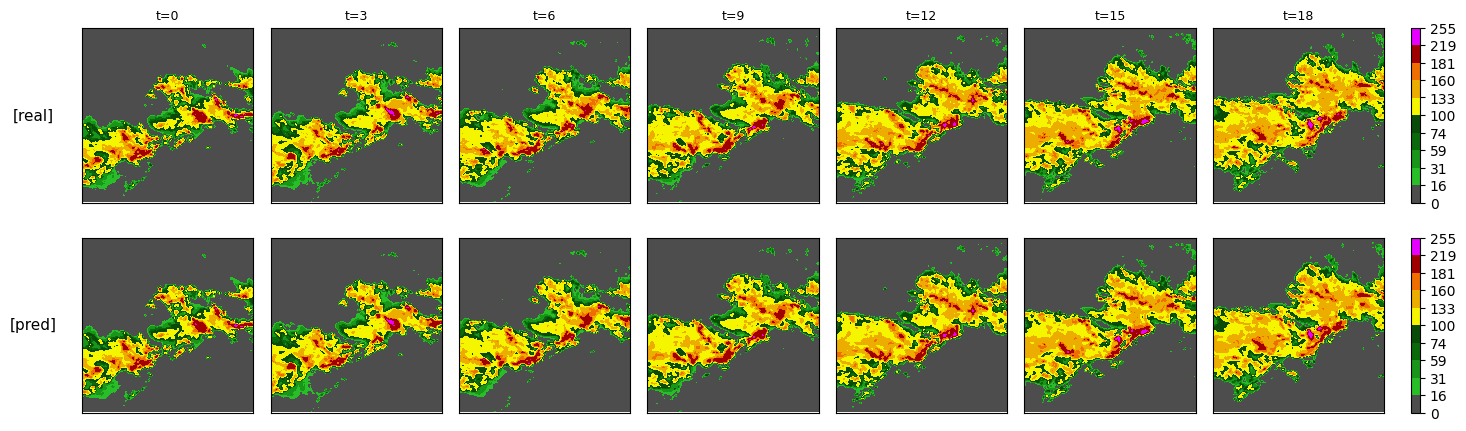

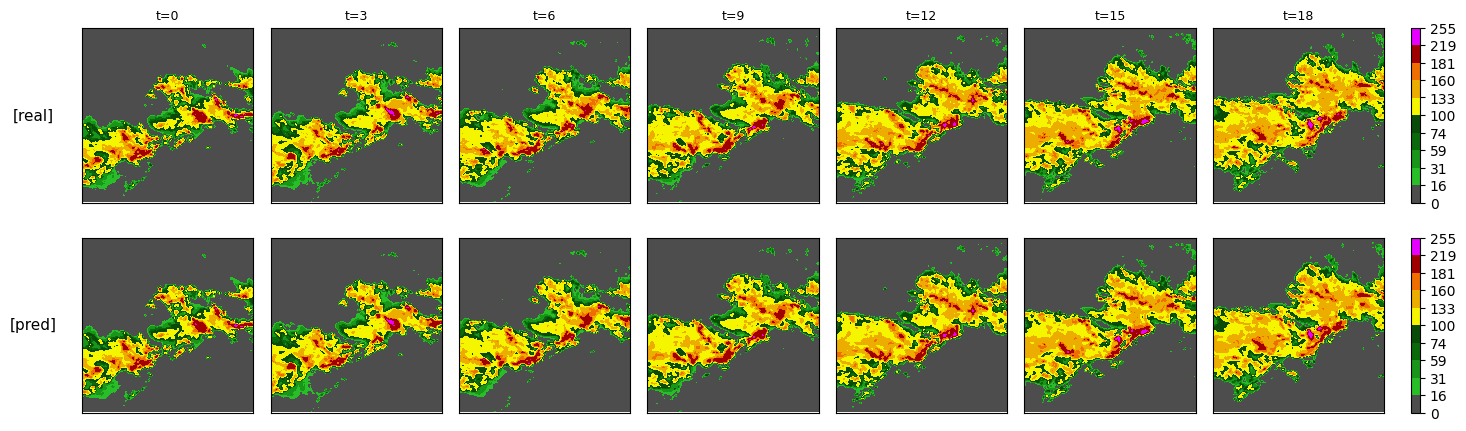

In [53]:
it = iter(test_loader)
batch = next(it)
batch = next(it)
batch = next(it)

data = batch['vil'].permute(0, 3, 1, 2).unsqueeze(2).to("cuda")
print(f"Input shape: {data.shape}")
pred = autoencoder.encode(data)
decoded = autoencoder.decode(pred)

real_data = data.squeeze(2).cpu().numpy()
pred_data = decoded.squeeze(2).cpu().numpy()
print(f"Real data shape: {real_data.shape}")
print(f"Predicted data shape: {pred_data.shape}")
plot_sample(
    sample={'real': real_data, 'pred': pred_data},
    batch_idx=0,
    save_dir="plots/sevir/",
    name="sample_plot.png",
    jump=3
)

In [45]:
it = iter(test_loader)
batch = next(it)
batch = next(it)
batch = next(it)

v = batch['vil'].permute(0,3,1,2).unsqueeze(2)
v = v.to("cuda")
v = autoencoder.encode(v)  # (B, T, LC, LH, LW)
v *= autoencoder.scaling_factor  

inp, tgt = v[:, :10], v[:, 10:]
inp_t = inp[:, -1, :, :, :].unsqueeze(1)
inp = inp - inp_t
tgt = tgt - inp_t
pred = model(inp)


In [46]:
pred += inp_t 
pred = pred / autoencoder.scaling_factor
decoded = autoencoder.decode(pred)
print(decoded.shape)  # (B, T, C, H, W)

torch.Size([8, 10, 1, 384, 384])


In [47]:
tgt += inp_t
tgt = tgt / autoencoder.scaling_factor
decoded_tgt = autoencoder.decode(tgt)

In [48]:
inp = inp + inp_t
inp = inp / autoencoder.scaling_factor
decoded_inp = autoencoder.decode(inp)

In [49]:
real_target = batch['vil'].permute(0,3,1,2)[:, 10:]
print(real_target.shape)  # (B, C, H, W)

torch.Size([8, 10, 384, 384])


(8, 10, 384, 384)
(8, 10, 384, 384)


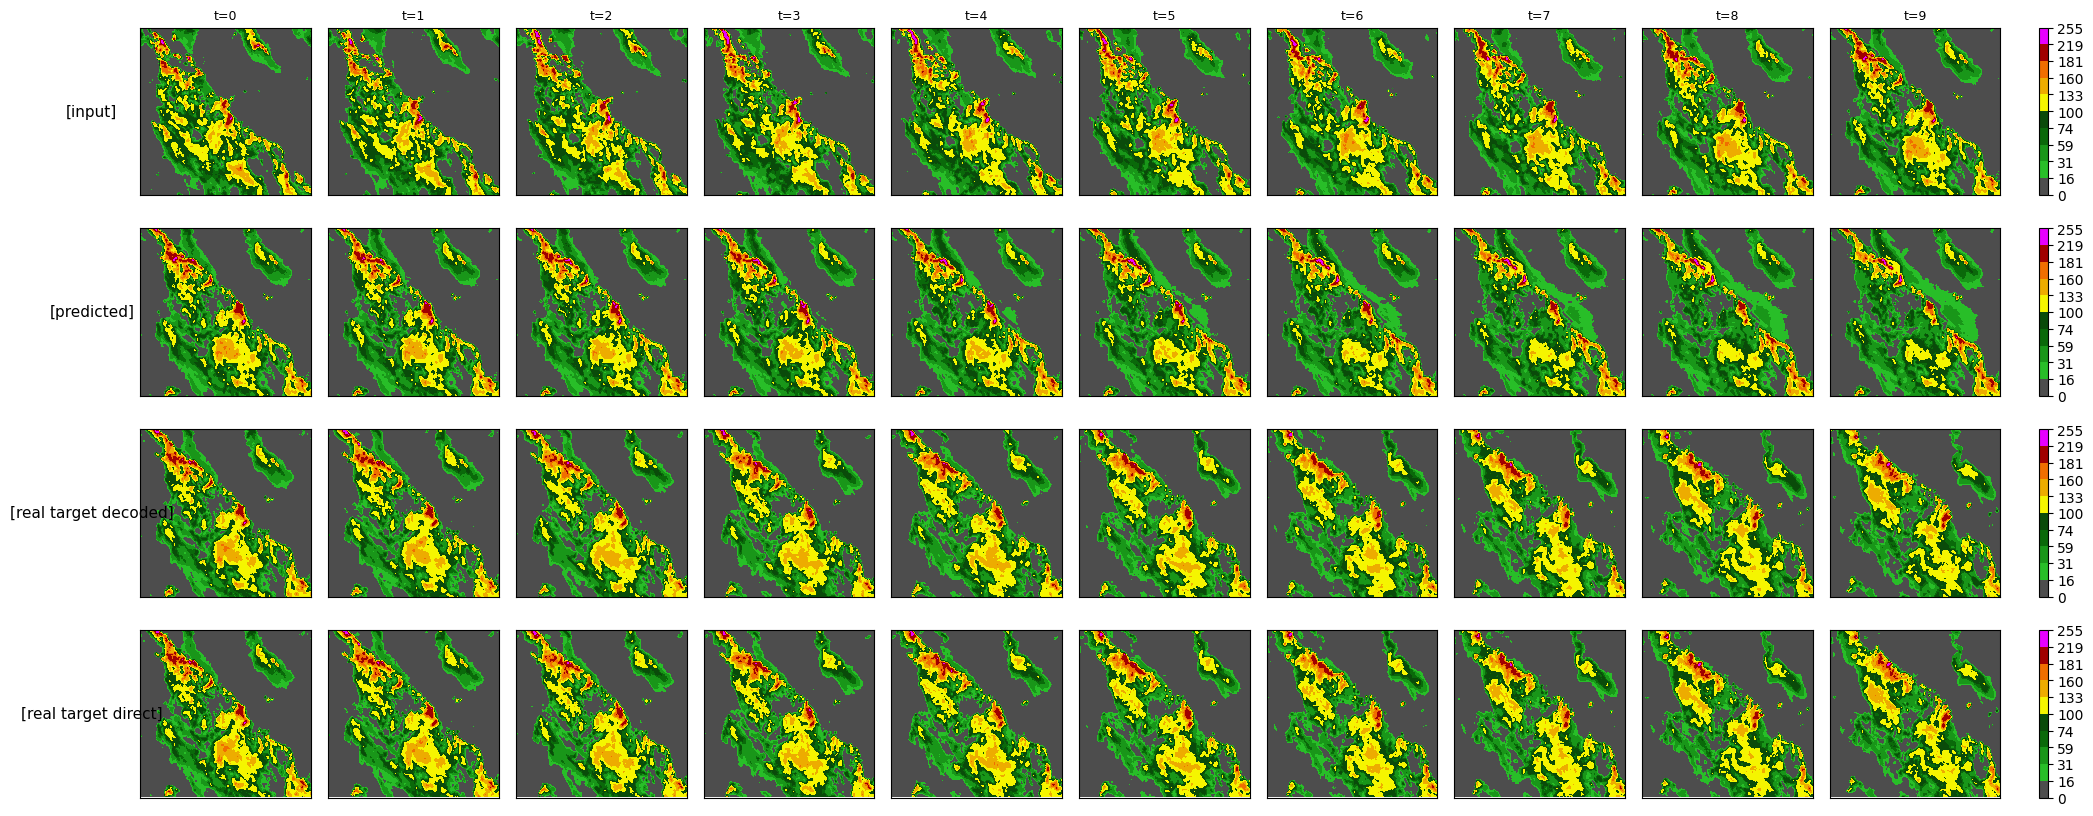

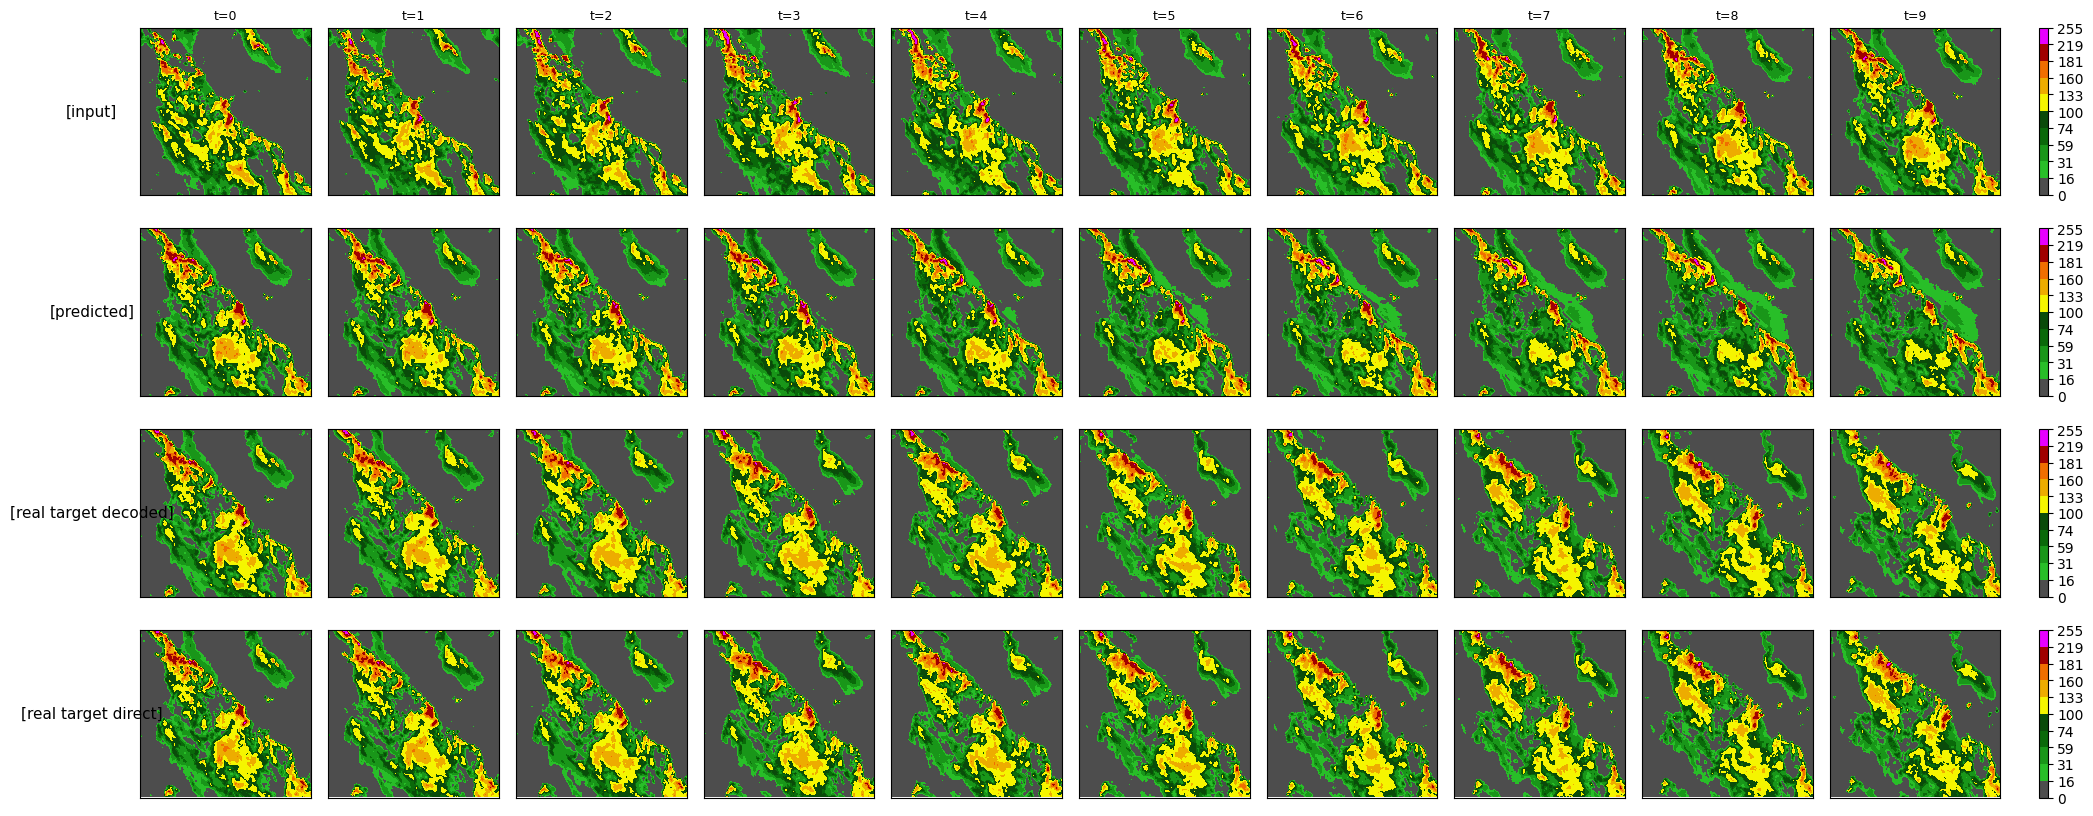

In [50]:
decoded_target = decoded_tgt.squeeze(2).detach().cpu().numpy()
decoded_plot = decoded.squeeze(2).detach().cpu().numpy()
decoded_inp_plot = decoded_inp.squeeze(2).detach().cpu().numpy()
print(decoded_plot.shape)  # (B, T, C, H, W)
print(decoded_target.shape)  # (B, T, C, H, W)
plot_sample({
    'input': decoded_inp_plot,
    "predicted": decoded_plot,
    "real target decoded" : decoded_target,
    "real target direct": real_target.numpy()
}, batch_idx=4)